In [2]:
import pandas as pd

# Load the Excel file from OneDrive
df = pd.read_excel(r"C:\Users\CHARMILA\OneDrive\Documents\Agri dataset.xlsx")

# Show first 5 rows
df.head()

,Farmer_ID,Age,Land_Area,Soil_Type,Sunlight_Hours,Water_Freq,Fertilizer_Type,Temperature,Humidity,Past_Loan_Status,Income,Loan_Amount_Requested,Loan_Approved
0,1,41,3.1,Clay,5,4,Organic,28,74,Bad,10000,75584,No
1,2,54,4.1,Loamy,8,5,Chemical,27,61,Bad,17500,87760,Yes
2,3,41,2.0,Sandy,8,5,Chemical,34,52,Good,15900,47978,Yes
3,4,33,3.7,Loamy,4,3,Chemical,30,74,Bad,14400,92389,No
4,5,22,1.1,Sandy,7,3,Chemical,35,80,Good,9400,24279,No


In [3]:
# Show first 5 rows
df.head()

# See columns, datatypes, and non-null counts
df.info()


# Quick summary of numeric columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Farmer_ID              10000 non-null  int64  
 1   Age                    10000 non-null  int64  
 2   Land_Area              10000 non-null  float64
 3   Soil_Type              10000 non-null  str    
 4   Sunlight_Hours         10000 non-null  int64  
 5   Water_Freq             10000 non-null  int64  
 6   Fertilizer_Type        10000 non-null  str    
 7   Temperature            10000 non-null  int64  
 8   Humidity               10000 non-null  int64  
 9   Past_Loan_Status       6990 non-null   str    
 10  Income                 10000 non-null  int64  
 11  Loan_Amount_Requested  10000 non-null  int64  
 12  Loan_Approved          10000 non-null  str    
dtypes: float64(1), int64(8), str(4)
memory usage: 1015.8 KB


,Farmer_ID,Age,Land_Area,Sunlight_Hours,Water_Freq,Temperature,Humidity,Income,Loan_Amount_Requested
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,40.541900,2.765240,5.99580,3.491500,30.04000,65.090200,13933.070000,62233.899100
std,2886.89568,10.828757,1.300146,1.40356,1.118236,3.17235,9.056316,4208.759525,29584.888246
min,1.00000,22.000000,0.500000,4.00000,2.000000,25.00000,50.000000,5000.000000,10010.000000
25%,2500.75000,31.000000,1.600000,5.00000,2.000000,27.00000,57.000000,10900.000000,36838.000000
50%,5000.50000,40.000000,2.800000,6.00000,3.000000,30.00000,65.000000,13300.000000,62080.000000
75%,7500.25000,50.000000,3.900000,7.00000,4.000000,33.00000,73.000000,16400.000000,87290.000000
max,10000.00000,59.000000,5.000000,8.00000,5.000000,35.00000,80.000000,30000.000000,124940.000000


In [4]:
df.isnull().sum()

Farmer_ID                   0
Age                         0
Land_Area                   0
Soil_Type                   0
Sunlight_Hours              0
Water_Freq                  0
Fertilizer_Type             0
Temperature                 0
Humidity                    0
Past_Loan_Status         3010
Income                      0
Loan_Amount_Requested       0
Loan_Approved               0
dtype: int64

In [5]:
import pandas as pd

# Load dataset
df = pd.read_excel(r"C:\Users\CHARMILA\OneDrive\Documents\Agri dataset.xlsx")

# Fill missing Past_Loan_Status using mode (without inplace warning)
mode_value = df['Past_Loan_Status'].mode()[0]
df['Past_Loan_Status'] = df['Past_Loan_Status'].fillna(mode_value)

# Confirm no missing values
print(df.isnull().sum())

Farmer_ID                0
Age                      0
Land_Area                0
Soil_Type                0
Sunlight_Hours           0
Water_Freq               0
Fertilizer_Type          0
Temperature              0
Humidity                 0
Past_Loan_Status         0
Income                   0
Loan_Amount_Requested    0
Loan_Approved            0
dtype: int64


In [6]:
# Convert categorical columns to numeric
df = pd.get_dummies(df, columns=['Soil_Type', 'Fertilizer_Type', 'Past_Loan_Status'])

# Check the first 5 rows
df.head()


,Farmer_ID,Age,Land_Area,Sunlight_Hours,Water_Freq,Temperature,Humidity,Income,Loan_Amount_Requested,Loan_Approved,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Fertilizer_Type_Chemical,Fertilizer_Type_Organic,Past_Loan_Status_Bad,Past_Loan_Status_Good
0,1,41,3.1,5,4,28,74,10000,75584,No,True,False,False,False,True,True,False
1,2,54,4.1,8,5,27,61,17500,87760,Yes,False,True,False,True,False,True,False
2,3,41,2.0,8,5,34,52,15900,47978,Yes,False,False,True,True,False,False,True
3,4,33,3.7,4,3,30,74,14400,92389,No,False,True,False,True,False,True,False
4,5,22,1.1,7,3,35,80,9400,24279,No,False,False,True,True,False,False,True


In [7]:
# Features (all columns except Loan_Approved)
X = df.drop(columns=['Loan_Approved'])

# Target (convert Yes/No to 1/0)
y = df['Loan_Approved'].map({'Yes':1, 'No':0})

# Check shapes
print(X.shape, y.shape)


(10000, 16) (10000,)


In [8]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 16) (2000, 16) (8000,) (2000,)


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create random forest model with 100 decison tress to predict loan approval



model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8905

Confusion Matrix:
 [[ 498  184]
 [  35 1283]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.73      0.82       682
           1       0.87      0.97      0.92      1318

    accuracy                           0.89      2000
   macro avg       0.90      0.85      0.87      2000
weighted avg       0.89      0.89      0.89      2000



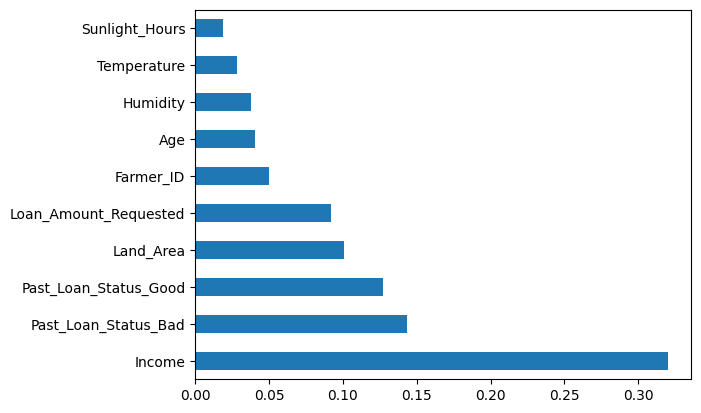

In [14]:
import matplotlib.pyplot as plt

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()


In [16]:
import joblib
joblib.dump(model, 'loan_model.pkl')


['loan_model.pkl']

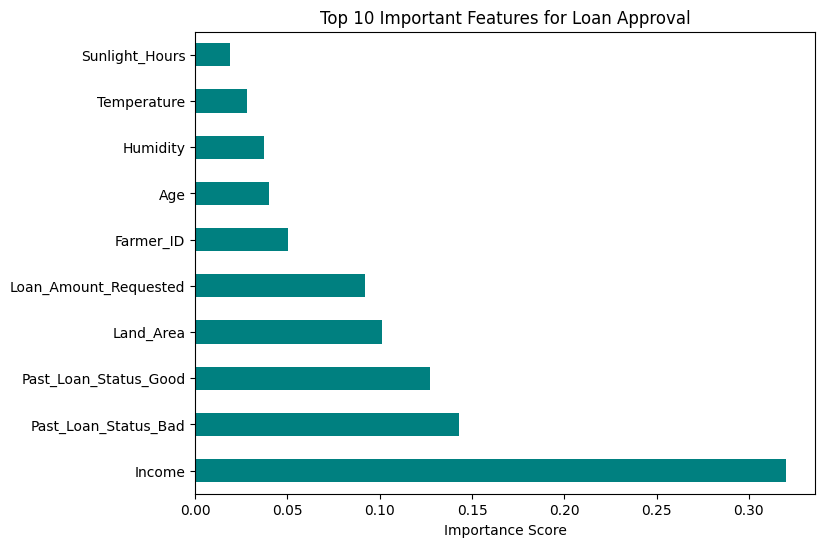

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from Random Forest
feat_importances = pd.Series(model.feature_importances_, index=X.columns)

# Plot top 10 important features
feat_importances.nlargest(10).plot(kind='barh', figsize=(8,6), color='teal')
plt.title("Top 10 Important Features for Loan Approval")
plt.xlabel("Importance Score")
plt.show()

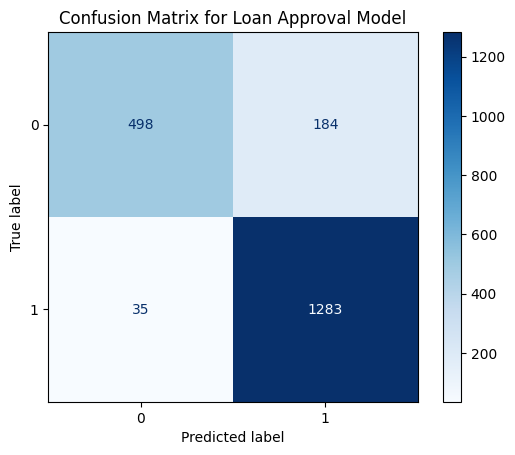

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Loan Approval Model")
plt.show()


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.73      0.82       682
           1       0.87      0.97      0.92      1318

    accuracy                           0.89      2000
   macro avg       0.90      0.85      0.87      2000
weighted avg       0.89      0.89      0.89      2000



In [21]:
import joblib

# Save trained Random Forest model
joblib.dump(model, 'loan_model.joblib')

['loan_model.joblib']